## 200. 岛屿数量

给你一个由 '1'（陆地）和 '0'（水）组成的的二维网格，请你计算网格中岛屿的数量。

岛屿总是被水包围，并且每座岛屿只能由水平方向和/或竖直方向上相邻的陆地连接形成。

此外，你可以假设该网格的四条边均被水包围。

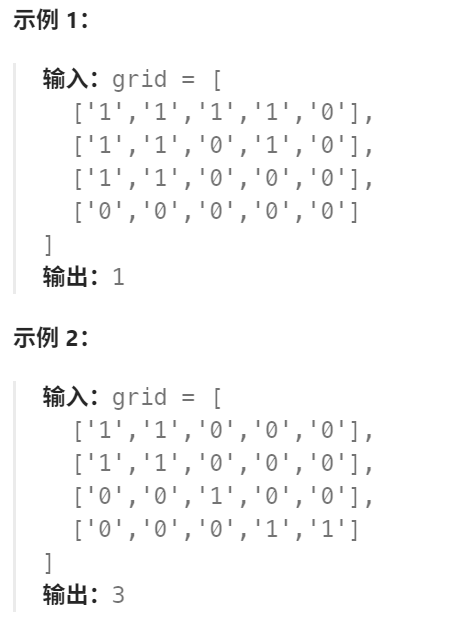

In [20]:
class Solution:
    def numIslands(self, grid):
        m, n = len(grid), len(grid[0])
        res = 0
        def dfs(l, r):
            if l<0 or l>=m or r<0 or r>=n or grid[l][r] != "1":
                return
            grid[l][r] = "0"
            dfs(l-1, r)
            dfs(l+1, r)
            dfs(l, r-1)
            dfs(l, r+1)
        for i in range(m):
            for j in range(n):
                if grid[i][j] == "1":
                    dfs(i, j)
                    res += 1
        return res
grid = [['1', '1', '0', '0', '0'],
        ['1', '1', '0', '0', '0'],
        ['0', '0', '1', '0', '0'],
        ['0', '0', '0', '1', '1'],]
print(Solution().numIslands(grid))


3


**核心思路**

该问题本质是 **二维网格中的连通分量统计问题（Connected Components）**。
每一块由 `'1'` 组成且通过 **上下左右四个方向相连** 的区域就是一个岛屿。

基本思想是：

当遍历到一个未访问过的 `'1'` 时，说明发现了一座新的岛屿。
随后从这个位置出发，通过 **DFS 或 BFS** 把与它相连的所有 `'1'` 全部访问并标记，避免重复统计。

整个过程可以理解为：

1. **遍历整个网格**
2. 如果当前格子是 `'1'`：

   * 岛屿数量 `+1`
   * 从该点开始进行 DFS/BFS
   * 将所有相连的 `'1'` 标记为已访问（例如改为 `'0'`）
3. 继续遍历剩余网格

这样，每个岛屿只会被统计一次。


**算法流程**

1. 遍历 `m × n` 网格中的每一个位置 `(i, j)`
2. 若 `grid[i][j] == '1'`：

   * 岛屿数量 `count += 1`
   * 启动 DFS / BFS
3. 在搜索过程中：

   * 访问当前位置
   * 将其标记为 `'0'`
   * 向四个方向继续搜索相邻陆地
4. 搜索结束后，该岛屿所有陆地已被标记
5. 最终 `count` 即为岛屿数量


**为什么这样做是正确的**

因为题目定义：

* 一个岛屿是 **上下左右连通的陆地集合**
* DFS/BFS 会把该连通块中的所有陆地一次性遍历

因此每发现一个新的 `'1'`，就等价于发现了一个新的 **连通分量**。

本题实际上就是在求：

**网格图中的连通分量数量。**


**复杂度分析**

设网格大小为 `m × n`。

时间复杂度：

$$
O(m \times n)
$$

原因：

* 每个格子最多被访问一次
* DFS/BFS 过程中不会重复访问已经标记的格子

空间复杂度：

DFS 递归实现：

$$
O(m \times n)
$$

最坏情况下（整个网格都是陆地），递归深度可能达到 `m × n`。

若使用 BFS：

$$
O(\min(m,n))
$$

或最坏 `O(m × n)`（队列存储整个连通块）。


**本题的算法本质**

该题属于经典问题：

**网格中的连通分量统计**

常见同类问题：

* 200. Number of Islands
* 695. Max Area of Island
* 130. Surrounded Regions
* 1254. Number of Closed Islands

统一思想：

**遍历网格 + DFS/BFS 扩散 + 标记访问状态。**

---

## 994. 腐烂的橘子

在给定的 m x n 网格 grid 中，每个单元格可以有以下三个值之一：

值 0 代表空单元格；

值 1 代表新鲜橘子；

值 2 代表腐烂的橘子。

每分钟，腐烂的橘子 周围 4 个方向上相邻 的新鲜橘子都会腐烂。

返回 直到单元格中没有新鲜橘子为止所必须经过的最小分钟数。如果不可能，返回 -1 。

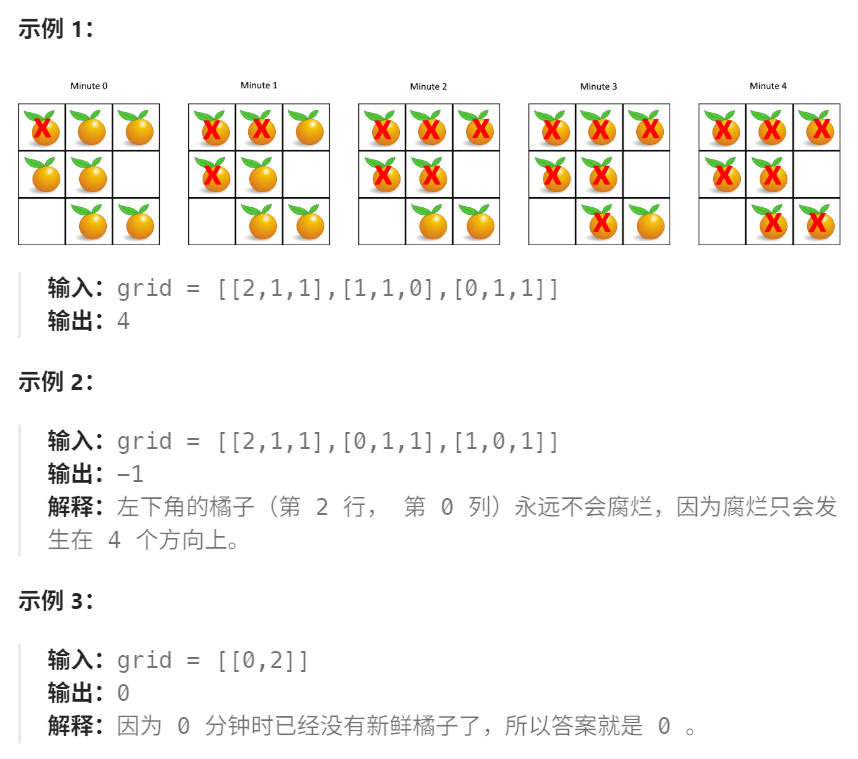

In [21]:
from collections import deque
class Solution:
    def orangesRotting(self, grid):
        m, n = len(grid), len(grid[0])
        funan_queue = deque()
        fresh = 0
        for i in range(m):
            for j in range(n):
                if grid[i][j] == 1:
                    fresh += 1
                elif grid[i][j] == 2:
                    funan_queue.append((i, j))
        if fresh == 0:
            return 0
        minutes = 0
        expand = [(1, 0), (-1, 0), (0, 1), (0, -1)]
        while funan_queue:
            size = len(funan_queue)
            valid = False
            for _ in range(size):
                x, y = funan_queue.popleft()
                for a, b in expand:
                    nx = x + a
                    ny = y + b
                    if 0 <= nx < m and 0<= ny < n and grid[nx][ny] == 1:
                        grid[nx][ny] = 2
                        funan_queue.append((nx, ny))
                        fresh -= 1
                        valid = True
            if valid:
                minutes += 1
        return minutes if fresh == 0 else -1

grid = [[2, 1, 1],
        [1, 1, 0],
        [0, 1, 1]]
print(Solution().orangesRotting(grid))

4


**核心思路**

该问题本质是一个 **网格上的多源最短传播问题**。腐烂橘子会在每一分钟向四个方向传播，因此“分钟数”实际上等价于 **从腐烂橘子到新鲜橘子的最短距离层数**。最合适的算法是 **多源 BFS（Breadth-First Search）**。

思考方式如下：

1. **所有腐烂橘子同时作为传播源**
   在时间 `t=0` 时，所有值为 `2` 的格子已经是腐烂状态，因此它们都是 BFS 的起点。

2. **BFS按层扩散代表时间推进**
   BFS 的每一层代表 **1分钟传播**。
   当前层的腐烂橘子会使相邻的四个方向的新鲜橘子腐烂。

3. **传播规则**

   * 如果邻居是 `1`（新鲜橘子）

     * 将其变为 `2`
     * 加入队列
     * 新鲜橘子数量减一
   * 如果是 `0`（空格）或已经腐烂，则跳过

4. **结束条件**

   * 如果 BFS 过程中 **所有新鲜橘子都被腐烂** → 返回经过的分钟数
   * 如果 BFS 结束后 **仍然存在新鲜橘子** → 说明存在无法被传播到的区域，返回 `-1`

核心思想可以总结为：

**“把所有腐烂橘子作为起点，同时向外层层扩散，每一层代表一分钟。”**

---

**算法流程**

1. 遍历网格：

   * 统计新鲜橘子数量 `fresh`
   * 将所有腐烂橘子 `(i,j)` 加入队列

2. 进行 BFS：

   * 每次处理当前队列的一层
   * 向四个方向扩散腐烂

3. 统计时间：

   * 每扩散一层时间 `+1`

4. BFS结束后：

   * 若 `fresh == 0` 返回时间
   * 否则返回 `-1`

---

**为什么不用 DFS**

DFS 会沿某条路径不断深入，例如：

```
2 → 1 → 1 → 1 → ...
```

这种方式得到的是 **路径深度**。

而题目需要的是 **所有橘子同时传播的最短时间**，这属于 **层级扩散问题**，必须使用 BFS。

---

**复杂度分析**

设网格大小为 `m × n`。

时间复杂度：

$$
O(m \times n)
$$

原因：

* 每个格子最多被访问一次
* 每个格子最多入队一次

空间复杂度：

$$
O(m \times n)
$$

原因：

* 队列在最坏情况下可能存储整个网格的节点。

---

**本题的算法本质**

可以抽象为一个经典模型：

**多源 BFS（Multi-source BFS）**

常见同类问题包括：

* 542. 01 Matrix
* 286. Walls and Gates
* 1162. As Far from Land as Possible

这些题的共同特点都是：

**多个起点 + 网格扩散 + 最短时间 / 最短距离。**

---


## 207. 课程表

你这个学期必须选修 numCourses 门课程，记为 0 到 numCourses - 1 。

在选修某些课程之前需要一些先修课程。 先修课程按数组 prerequisites 给出，其中 prerequisites[i] = [ai, bi] ，表示如果要学习课程 ai 则 必须 先学习课程  bi 。

例如，先修课程对 [0, 1] 表示：想要学习课程 0 ，你需要先完成课程 1 。
请你判断是否可能完成所有课程的学习？如果可以，返回 true ；否则，返回 false 。

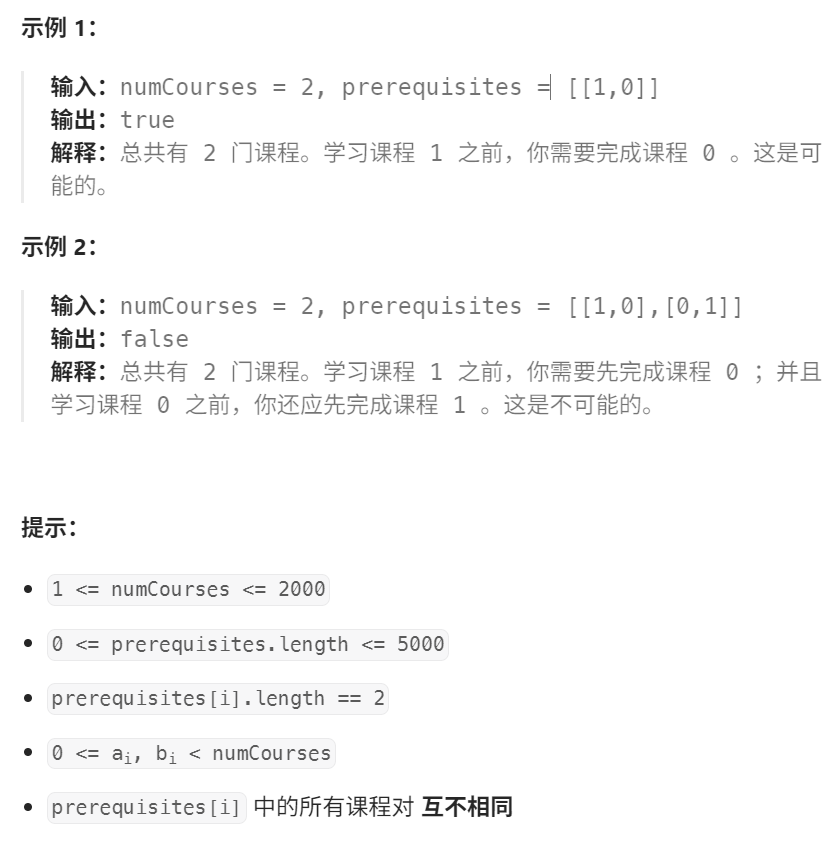

In [22]:
from collections import defaultdict, deque

class Solution:
    def canFinish(self, numCourses: int, prerequisites):

        # 构建图
        graph = defaultdict(list)

        # 入度数组
        indegree = [0] * numCourses

        for a, b in prerequisites:
            graph[b].append(a)
            indegree[a] += 1

        # 入度为0的课程
        queue = deque()

        for i in range(numCourses):
            if indegree[i] == 0:
                queue.append(i)

        finished = 0

        while queue:

            course = queue.popleft()
            finished += 1

            for next_course in graph[course]:

                indegree[next_course] -= 1

                if indegree[next_course] == 0:
                    queue.append(next_course)

        return finished == numCourses
numCourses = 4
prerequisites = [[3,1], [3, 2], [1, 0], [2, 0]]
print(Solution().canFinish(numCourses, prerequisites))

True


**核心思路（拓扑排序）**

本题可以抽象为一个 **有向图是否存在环的问题**。

将每一门课程看作一个节点，如果存在先修关系 `prerequisites[i] = [a, b]`，表示学习课程 `a` 之前必须先完成课程 `b`，因此可以建立一条有向边：

$$
b \rightarrow a
$$
这表示 **课程 b 是课程 a 的前置节点**。
如果图中存在环，例如：

$$
0 \rightarrow 1 \rightarrow 0
$$

那么课程之间形成循环依赖，就无法完成所有课程。

判断是否存在环可以通过 **拓扑排序（Topological Sort）** 实现。

具体步骤如下：

1. **构建图结构**

   * 使用邻接表表示课程之间的依赖关系。
   * 同时维护每个节点的 **入度（indegree）**，即有多少先修课程。

2. **初始化队列**

   * 将所有 **入度为 0 的课程**加入队列。
   * 入度为 0 表示该课程没有任何先修要求，可以直接学习。

3. **执行拓扑排序（BFS）**

   * 从队列中取出一个课程，表示完成该课程。
   * 将其所有后继课程的入度减 1。
   * 如果某个课程的入度变为 0，则加入队列。

4. **统计完成课程数量**

   * 每从队列取出一个课程，说明完成了一门课程。
   * 最终如果完成课程数等于 `numCourses`，说明不存在环，可以完成所有课程。
   * 否则说明图中存在环，部分课程无法被学习。

该过程本质是 **逐步删除入度为 0 的节点，如果最终仍然存在节点未被删除，则说明存在环**。


**复杂度分析**

设：

* (V =) 课程数量 `numCourses`
* (E =) 先修关系数量 `len(prerequisites)`

时间复杂度：

$$
O(V + E)
$$

原因：

* 构建邻接表需要遍历所有边 (O(E))
* 每个节点最多入队和出队一次 (O(V))
* 每条边在更新入度时被访问一次 (O(E))

空间复杂度：

$$
O(V + E)
$$

原因：

* 邻接表需要存储所有边 (O(E))
* 入度数组大小为 (O(V))
* 队列最多存储 (O(V)) 个节点。

**本题本质**

本题是一个经典的 **拓扑排序判环问题**：

* **无环 → 可以完成所有课程**
* **有环 → 无法完成课程学习**

因此核心就是利用 **入度 + BFS 的拓扑排序算法检测有向图中的环。**

---

## 208. 实现 Trie (前缀树)

Trie（发音类似 "try"）或者说 前缀树 是一种树形数据结构，用于高效地存储和检索字符串数据集中的键。这一数据结构有相当多的应用情景，例如自动补全和拼写检查。

请你实现 Trie 类：

- Trie() 初始化前缀树对象。
- void insert(String word) 向前缀树中插入字符串 word 。
- boolean search(String word) 如果字符串 word 在前缀树中，返回 true（即，在检索之前已经插入）；否则，返回 false 。
- boolean startsWith(String prefix) 如果之前已经插入的字符串 word 的前缀之一为 prefix ，返回 true ；否则，返回 false 。
  
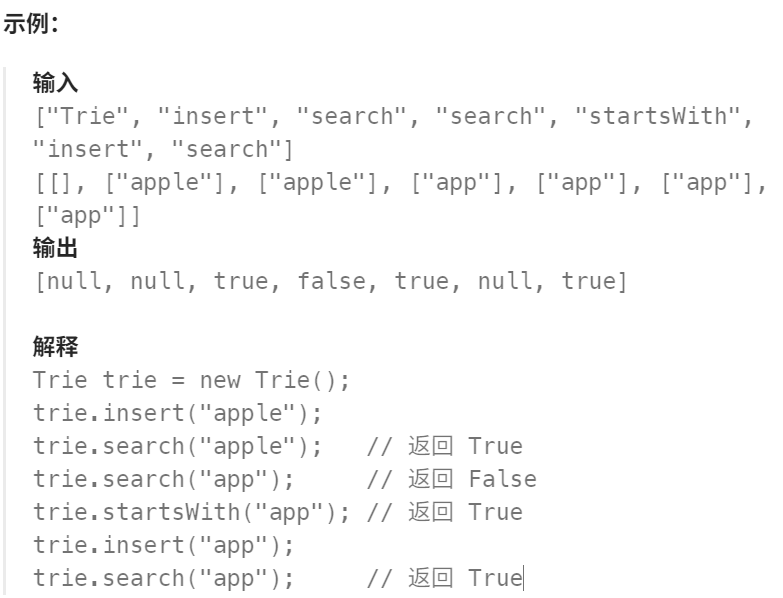

In [23]:
class TrieNode:

    def __init__(self):
        self.children = {}
        self.is_end = False


class Trie:

    def __init__(self):
        self.root = TrieNode()


    def insert(self, word: str) -> None:

        node = self.root

        for ch in word:
            if ch not in node.children:
                # 创建一个新的子节点
                node.children[ch] = TrieNode()
            # 移动指针到这个子节点
            node = node.children[ch]

        node.is_end = True


    def search(self, word: str) -> bool:

        node = self.root

        for ch in word:
            if ch not in node.children:
                return False

            node = node.children[ch]

        return node.is_end


    def startsWith(self, prefix: str) -> bool:

        node = self.root

        for ch in prefix:
            if ch not in node.children:
                return False

            node = node.children[ch]

        return True
trie = Trie()
print(trie.insert("apple"))
print(trie.search("apple"))
print(trie.search("app"))
print(trie.startsWith("app"))
print(trie.insert("app"))
print(trie.insert("pfc"))
print(trie.search("pfc"))
print(trie.search("app"))


None
True
False
True
None
None
True
True


**核心思路**

Trie（前缀树）是一种专门用于 **字符串前缀匹配** 的树形数据结构。本题要求实现三种操作：

* 插入单词 `insert`
* 查找完整单词 `search`
* 查找前缀 `startsWith`

Trie 的核心思想是：

**将字符串按字符逐层拆分，并把公共前缀共享为同一条路径。**

在实现中：

* 每个节点表示一个字符路径
* 每个节点维护：

  * `children`：子节点集合（通常用字典存储）
  * `is_end`：标记该节点是否是一个完整单词的结尾

Trie 的根节点表示 **空字符串**。

例如插入：

```
apple
app
```

Trie 结构：

```
root
 |
 a
 |
 p
 |
 p (end)
 |
 l
 |
 e (end)
```

其中：

* `app` 在第三层结束
* `apple` 在第五层结束


一、insert 操作

插入字符串时：

1. 从根节点开始
2. 按字符逐个遍历
3. 如果当前字符路径不存在，就创建新的节点
4. 指针移动到该节点
5. 当所有字符遍历完成，将当前节点标记为 `is_end = True`

本质是：

```
从 root 沿字符路径逐层创建节点
```

二、search 操作

查找完整单词时：

1. 从根节点开始
2. 按字符逐个查找
3. 如果某个字符路径不存在 → 返回 `False`
4. 如果路径存在，继续向下
5. 最终检查节点 `is_end`

只有当：

```
路径存在 且 is_end = True
```

才表示该单词被插入过。


三、startsWith 操作

与 `search` 类似，但只需要判断：

```
prefix 路径是否存在
```

不需要检查 `is_end`。

只要路径存在，就说明 Trie 中有单词具有该前缀。


四、Trie 的本质结构

Trie 可以看作：

```
多叉树（每个节点最多 26 个子节点）
```

路径表示：

```
root → 字符1 → 字符2 → ... → 字符k
```

表示字符串前缀。


五、复杂度分析

设：

* (L) = 查询字符串长度
* (N) = 已存储单词数量

1 insert

时间复杂度：

$
O(L)
$

原因：

需要遍历字符串的每个字符。

空间复杂度：

$
O(L)
$

最坏情况下每个字符都需要创建新节点。

2 search

时间复杂度：
$
O(L)
$

只需沿着 Trie 向下遍历字符路径。

空间复杂度：

$
O(1)
$

不需要额外空间。

3 startsWith

时间复杂度：

$
O(L)
$

仅检查前缀路径。

空间复杂度：

$
O(1)
$


六、Trie 的优势

Trie 在以下场景非常高效：

* 自动补全（Autocomplete）
* 拼写检查
* 字典查询
* 前缀搜索
* 敏感词过滤

因为其查找复杂度：

```
O(字符串长度)
```

而不是：

```
O(单词数量)
```

---

**总结**

Trie 的核心思想是：

```
利用树结构共享字符串前缀
```

三种操作本质上都是：

```
从 root 沿字符路径向下遍历
```

其时间复杂度均为：

$
O(L)
$

其中 (L) 为字符串长度。
